In [34]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [35]:
df = pd.read_csv('Car_Speed_Mileage.csv')
df.head() 

,Speed_kmph,Mileage_kmpl
0,22.5,14.97
1,27.0,16.96
2,36.7,17.41
3,38.7,19.75
4,38.7,18.48


<Axes: xlabel='Speed_kmph', ylabel='Mileage_kmpl'>

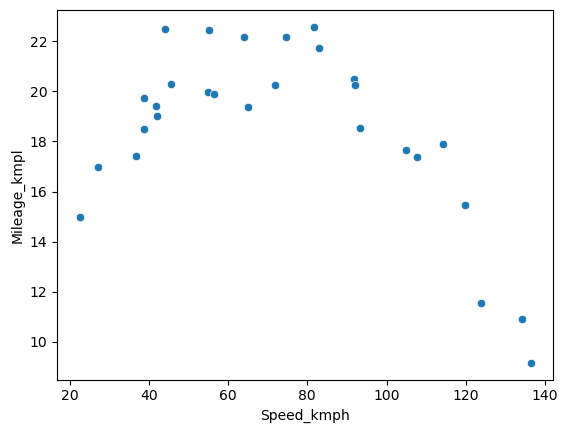

In [36]:
sns.scatterplot(x=df['Speed_kmph'],y=df['Mileage_kmpl'])

In [37]:
y = df['Mileage_kmpl']
x = df.drop(columns=['Mileage_kmpl'],axis=1)

In [38]:
from sklearn.model_selection import train_test_split 
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [39]:
from sklearn.preprocessing import PolynomialFeatures 
poly = PolynomialFeatures(degree=2)

In [40]:
X_train_poly = poly.fit_transform(x_train)
X_test_poly = poly.transform(x_test)

In [41]:
from sklearn.linear_model import LinearRegression 
model = LinearRegression() 
model.fit(X_train_poly,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
y_pred = model.predict(X_test_poly)

In [43]:
from sklearn.metrics import r2_score 
score = r2_score(y_test,y_pred)
print(score)

0.8860575439757402


C:\Users\susha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


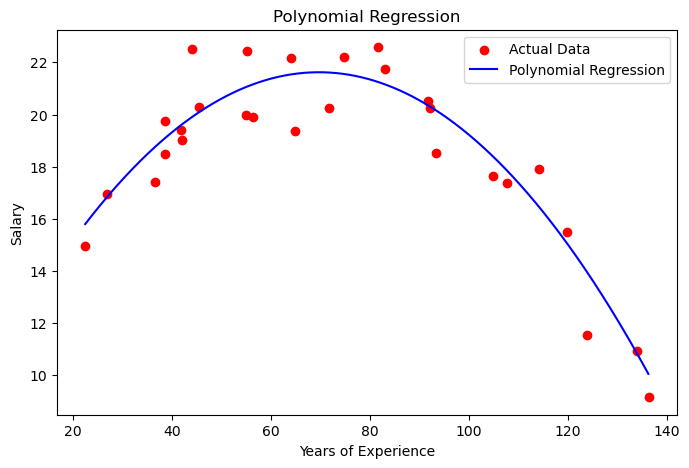

In [44]:
X_grid = np.arange(min(df['Speed_kmph']), max(df['Speed_kmph']), 0.1).reshape(-1,1)
plt.figure(figsize=(8,5))
plt.scatter(x, y, color='red', label='Actual Data')
plt.plot(X_grid,
         model.predict(poly.transform(X_grid)),
         color='blue',
         label='Polynomial Regression')
plt.title("Polynomial Regression")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend()
plt.show()

In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge,Lasso 
from sklearn.pipeline import Pipeline
ridge_model = Pipeline([
    ('poly',PolynomialFeatures(degree=10)), 
    ('scaler',StandardScaler()), 
    ('ridge',Ridge(alpha=0.1))
])
ridge_model.fit(x_train,y_train)
ridge_train_pred = ridge_model.predict(x_train)
ridge_test_pred = ridge_model.predict(x_test)

print("\nRidge (degree=10, alpha=0.1)") 
print("Train R2:", r2_score(y_train, ridge_train_pred)) 
print("Test R2 :", r2_score(y_test, ridge_test_pred))


Ridge (degree=10, alpha=0.1)
Train R2: 0.8793994266839611
Test R2 : 0.7648896728546718


C:\Users\susha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


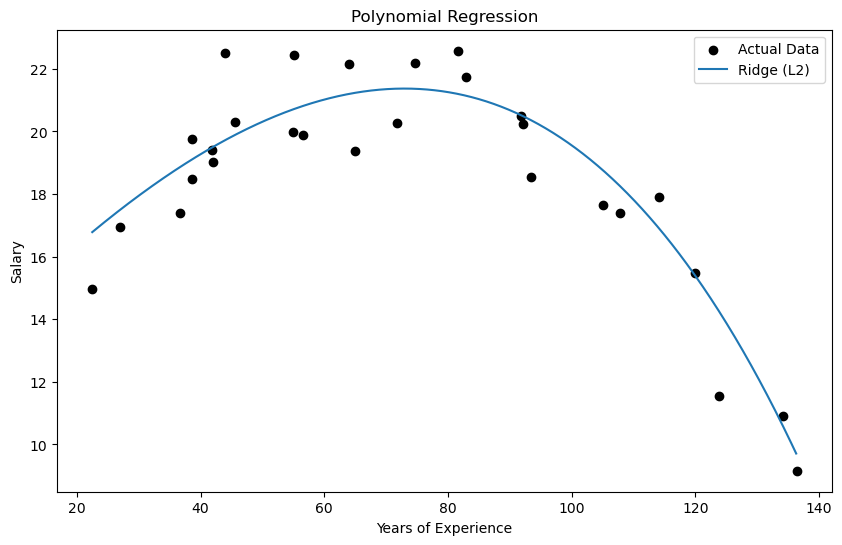

In [50]:
plt.figure(figsize=(10,6)) 
plt.scatter(x,y,color='black',label='Actual Data')
plt.plot(X_grid,ridge_model.predict(X_grid),label='Ridge (L2)') 
plt.title("Polynomial Regression")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend()
plt.show()

In [47]:
# from sklearn.linear_model import Ridge
# from sklearn.model_selection import GridSearchCV

# ridge = Ridge() 
# parameters = {
#     "alpha": np.logspace(-4, 4, 10)
# }

# ridge_regressor = GridSearchCV(ridge,parameters,scoring="r2",cv=5)
# ridge_regressor.fit(x_train,y_train)

# ridge_train_pred2 = ridge_regressor.predict(x_train)
# ridge_test_pred2 = ridge_regressor.predict(x_test)

# # print("\nRidge (degree=10, alpha=1)") 
# print("Train R2:", r2_score(y_train, ridge_train_pred2)) 
# print("Test R2 :", r2_score(y_test, ridge_test_pred2))
# print(ridge_regressor.best_params_) 

In [48]:
# np.logspace(-4, 4, 10)